In [85]:
#importing necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

#dataset
df = pd.read_csv('nba_shooting_and_offense.csv')

In [86]:
def three_pt_efficiency_model(data):
    """
    Uses skillet learns random forest classifer to predict the offensive rating of every NBA team based on
    the averages of the 3 pt percentage and 3 ptrs attempted per team.
    
    Parameters:
    data (pd.DataFrame): NBA df with the '3P%', '3PA', and 'ORtg' columns
    
    Returns:
    tuple: tuple with the predicted y's, tested y's, X predictors, and r2 value
    """

    #feature matrix X
    X = np.column_stack([  
        data['3P%'].values,  
        data['3PA'].values   
    ])

    #target variable y
    y = data['ORtg'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42)

    # Instantiate a RandomForestRegressor model
    # n_estimators is set to 100 by default, represents the number of trees made. A high n can cause overfitting
    # a low n can cause innacurate results
    model = RandomForestRegressor(n_estimators=100, random_state=42)

    # Fit the model to training data
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Get r2 Score
    r2 = r2_score(y_test, y_pred)

    return {
        'y_pred':y_pred,
        'y_test':y_test,
        'X':X,
        'r2':r2
    }

results = three_pt_efficiency_model(df)
results

{'y_pred': array([1.075  , 1.13352, 1.14179, 1.14331, 1.08406, 1.15525, 1.08713,
        1.06288, 1.14386]),
 'y_test': array([1.089, 1.1  , 1.135, 1.122, 1.063, 1.138, 1.116, 1.045, 1.144]),
 'X': array([[36.3, 37.7],
        [38.3, 42. ],
        [36.2, 36.7],
        [35.5, 34. ],
        [35.8, 32.1],
        [36.1, 36.3],
        [36.8, 38.2],
        [36.9, 31.3],
        [34.8, 31.7],
        [37.9, 38.8],
        [35.2, 36.1],
        [37.2, 34.9],
        [38.1, 33.1],
        [37.2, 31.1],
        [34.6, 37.8],
        [36.8, 33.8],
        [37.1, 37.6],
        [38.2, 32.7],
        [37.6, 32.4],
        [37. , 35.3],
        [38.5, 34.2],
        [34.8, 31.5],
        [36.4, 33.5],
        [38.1, 32.3],
        [34.5, 33.2],
        [36.6, 39.3],
        [34.7, 36.4],
        [34.7, 33.1],
        [35.4, 36.5],
        [34.8, 35.5]]),
 'r2': 0.611479050629954}

Some things I noticed for analysis...

RandomForestRegressor features that can be experimented with / fine tuned:
- n_estimators (number of trees): Too many trees can lead to overfitting, while too few may cause underfitting. You can tune this through cross-validation.

- max_depth: The maximum depth of each tree. Limiting this can prevent overfitting.

Data collection improvements that can be made:
- Increasing depth of data: More rows (past years, other leagues)

- Increasing length of data: More columns (pace of play, point in the season, % of team injured players)

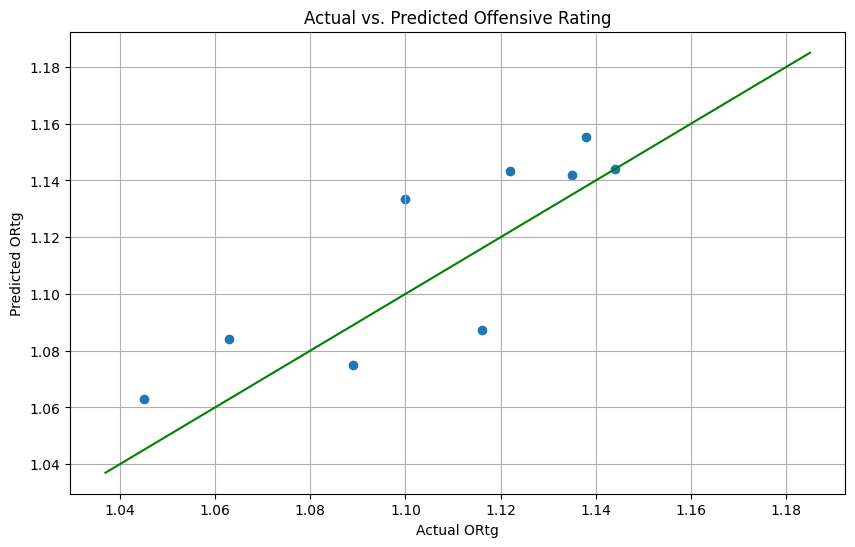

NBA Teams Overperforming Predictions:
   Predicted_ORtg  Prediction_Error
6         1.08713           0.02887
0         1.07500           0.01400
8         1.14386           0.00014
2         1.14179          -0.00679
5         1.15525          -0.01725
7         1.06288          -0.01788
4         1.08406          -0.02106
3         1.14331          -0.02131
1         1.13352          -0.03352

NBA Teams Underperforming Predictions:
   Predicted_ORtg  Prediction_Error
1         1.13352          -0.03352
3         1.14331          -0.02131
4         1.08406          -0.02106
7         1.06288          -0.01788
5         1.15525          -0.01725
2         1.14179          -0.00679
8         1.14386           0.00014
0         1.07500           0.01400
6         1.08713           0.02887


In [88]:
#graph of actual vs predicted vals
plt.figure(figsize=(10, 6))
plt.scatter(results['y_test'], results['y_pred'])
plt.plot([df['ORtg'].min(), df['ORtg'].max()], 
         [df['ORtg'].min(), df['ORtg'].max()], 'g-')
plt.xlabel('Actual ORtg')
plt.ylabel('Predicted ORtg')
plt.title('Actual vs. Predicted Offensive Rating')
plt.grid(True)
plt.show()

#comparing actual vs predicted vals
final = pd.DataFrame()
final['Predicted_ORtg'] = results['y_pred']
final['Prediction_Error'] = results['y_test'] - final['Predicted_ORtg']

print("NBA Teams Overperforming Predictions:")
print(final.nlargest(10, 'Prediction_Error')[['Predicted_ORtg', 'Prediction_Error']])

print("\nNBA Teams Underperforming Predictions:")
print(final.nsmallest(10, 'Prediction_Error')[['Predicted_ORtg', 'Prediction_Error']])